In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/student_productivity_distraction_dataset.csv')
df

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06


In [ ]:
df.shape

(20000, 18)

In [ ]:
df.isna().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
sleep_hours,0
phone_usage_hours,0
social_media_hours,0
youtube_hours,0
gaming_hours,0
breaks_per_day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
student_id,int64
age,int64
gender,object
study_hours_per_day,float64
sleep_hours,float64
phone_usage_hours,float64
social_media_hours,float64
youtube_hours,float64
gaming_hours,float64
breaks_per_day,int64


In [ ]:
from sklearn.preprocessing import OneHotEncoder
encode=LabelEncoder()
df['gender']=lab.fit_transform(df['gender'])

In [ ]:
x=df.drop(columns=['student_id','productivity_score'],axis=1)

In [ ]:
y=df['productivity_score']

In [ ]:
x.ndim

2

In [ ]:
y.ndim

1

In [ ]:
y.unique()

array([33.78, 48.99, 36.6 , ..., 78.14, 87.45, 17.84])

In [ ]:
df['gender'].value_counts()

,count
gender,
0,9640
1,9582
2,778


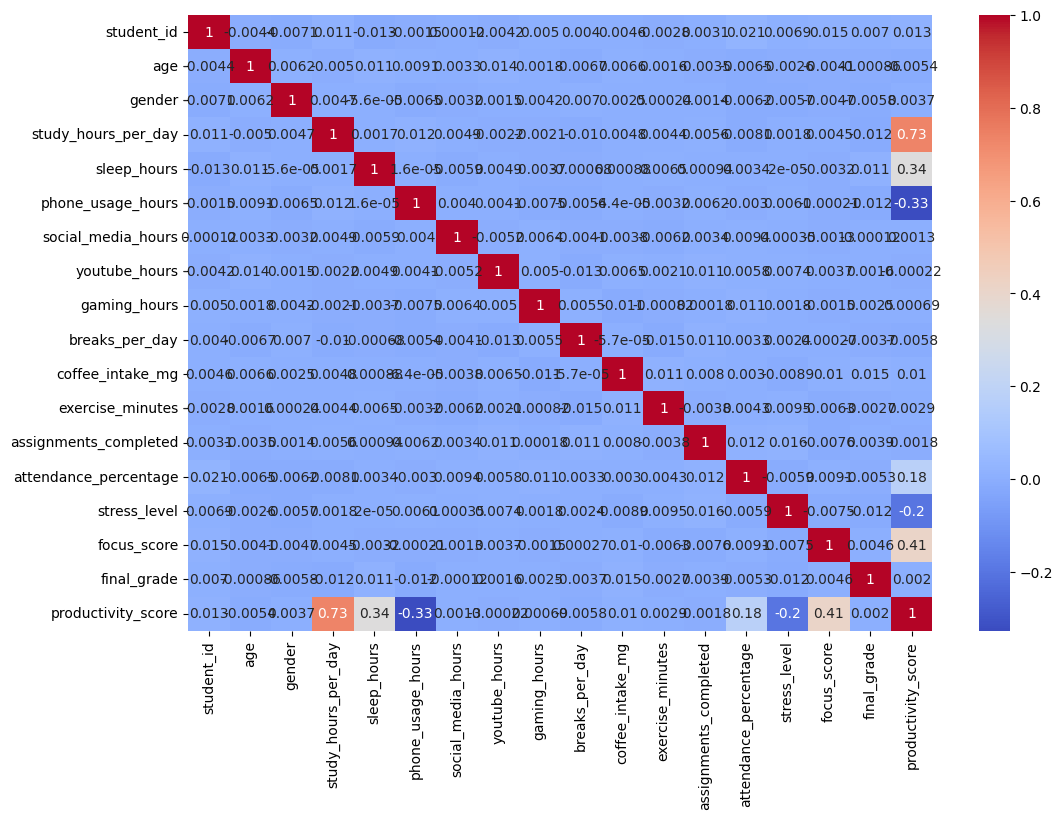

In [ ]:

plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

In [ ]:
df['gender'].value_counts()

,count
gender,
0,9640
1,9582
2,778


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [ ]:
x_train.value_counts()

age  gender  study_hours_per_day  sleep_hours  phone_usage_hours  social_media_hours  youtube_hours  gaming_hours  breaks_per_day  coffee_intake_mg  exercise_minutes  assignments_completed  attendance_percentage  stress_level  focus_score  final_grade
29   2       7.63                 4.44         5.62               0.38                5.38           4.82          9               420               102               14                     46.05                  9             66           99.88          1
             7.54                 4.51         0.83               0.05                2.49           3.05          8               192               11                8                      79.33                  1             73           52.13          1
             7.45                 5.24         11.51              5.37                3.58           3.95          9               401               48                6                      61.23                  2             42           51.31          1
             7.30                 8.07         0.94               5.65                0.70           3.73          3               447               21                7                      85.93                  2             59           52.88          1
             7.26                 6.57         2.04               6.17                2.93           4.13          9               263               24                10                     74.76                  10            77           65.89          1
                                                                                                                                                                                                                                                              ..
17   0       0.56                 6.56         1.51               2.54                2.21           3.65          1               474               10                19                     77.17                  8             98           86.63          1
             0.54                 7.06         6.30               6.00                1.98           3.43          7               142               27                3                      95.24                  5             62           56.59          1
             0.53                 9.84         7.73               2.48                2.79           2.56          13              56                106               7                      65.14                  9             62           62.09          1
                                  4.68         11.08              3.21                4.30           5.19          14              33                93                4                      82.74                  10            87           78.29          1
             0.50                 6.67         11.77              3.74                1.65           1.16          11              311               98                13                     97.24                  1             47           89.40          1
Name: count, Length: 16000, dtype: int64

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = [
    LinearRegression(),
    KNeighborsRegressor(),
    DecisionTreeRegressor(random_state=42),
    RandomForestRegressor(random_state=42)
]
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

for model in models:
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(model.__class__.__name__)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)
    print()


LinearRegression
MAE : 0.002483150428161976
RMSE: 0.0028723981148570813
R2  : 0.9999999679698651

KNeighborsRegressor
MAE : 4.932275
RMSE: 6.1820325681769095
R2  : 0.8516347891392824

DecisionTreeRegressor
MAE : 3.97452
RMSE: 4.985395500860489
R2  : 0.9035130150610734

RandomForestRegressor
MAE : 2.00184425
RMSE: 2.540526641031343
R2  : 0.9749436961067236



In [ ]:
import pickle

model = LinearRegression()
model.fit(x_train, y_train)

pickle.dump(model, open('productivity_model.pkl', 'wb'))


In [ ]:
import pickle

pickle.dump(scaler, open('scaler.pkl', 'wb'))